# PREDICTIVE ANALYSIS - Will an Order Get a Low Review Score (1-2 stars)?

Goal: predict `is_low_review` using order/delivery/payment features that are known **before** the review is posted.

Business use case: flag at-risk orders early so CX/marketing can intervene.

This notebook builds on `olist_Marketing_analysis.ipynb` - same `base` feature table, same target column (`is_low_review`) that was already created there.

## 0. Imports

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)
import joblib

sns.set_style("whitegrid")

## 1. Load Feature Base

In [0]:
orders = spark.table("workspace.default.olist_orders_dataset").toPandas()
customers = spark.table("workspace.default.olist_customers_dataset").toPandas()
products = spark.table("workspace.default.olist_products_dataset").toPandas()
order_items = spark.table("workspace.default.olist_order_items_dataset").toPandas()
payments = spark.table("workspace.default.olist_order_payments_dataset").toPandas()
reviews = spark.table("workspace.default.olist_order_reviews_dataset").toPandas()
cat_trans = spark.table("workspace.default.product_category_name_translation").toPandas()

products = products.merge(cat_trans, on="product_category_name", how="left")
products["product_category_name_english"] = products["product_category_name_english"].fillna("Uncategorized")

items_agg = order_items.groupby("order_id").agg(total_price=("price","sum"), total_freight=("freight_value","sum"), n_items=("order_item_id","count")).reset_index()
first_item = order_items.sort_values("order_item_id").groupby("order_id").first().reset_index()
first_item = first_item.merge(products[["product_id","product_category_name_english"]], on="product_id", how="left")
pay_agg = payments.groupby("order_id").agg(total_payment=("payment_value","sum"), max_installments=("payment_installments","max")).reset_index()
pay_type = payments.sort_values("payment_sequential").groupby("order_id").first()[["payment_type"]].reset_index()
rev_agg = reviews.groupby("order_id").agg(review_score=("review_score","max")).reset_index()
orders_c = orders.merge(customers, on="customer_id", how="left")

base = (orders_c.merge(items_agg, on="order_id", how="left")
               .merge(first_item[["order_id","product_category_name_english"]], on="order_id", how="left")
               .merge(pay_agg, on="order_id", how="left")
               .merge(pay_type, on="order_id", how="left")
               .merge(rev_agg, on="order_id", how="left"))

base["order_revenue"] = base["total_price"] + base["total_freight"]
base["is_late"] = (base["order_delivered_customer_date"] > base["order_estimated_delivery_date"]).astype(int)
base["is_low_review"] = (base["review_score"] <= 2).astype(int)
base["delivery_delay_days"] = (base["order_delivered_customer_date"] - base["order_estimated_delivery_date"]).dt.days
base["order_month_num"] = base["order_purchase_timestamp"].dt.month
base["order_dow_num"] = base["order_purchase_timestamp"].dt.dayofweek

base = base[base["order_purchase_timestamp"] < "2018-09-01"].copy()  # same cutoff as EDA notebook
print("Base shape:", base.shape)

Base shape: (99421, 26)


## 2. Define Target & Check Class Balance

In [0]:
print(base["is_low_review"].value_counts(normalize=True) * 100)

is_low_review
0    85.49401
1    14.50599
Name: proportion, dtype: float64


**Note:** Around **14–15% of orders have low review scores**, which is similar to the **14.6% detractor rate** found in the EDA analysis. This is not a very large percentage, but the classes are still unbalanced. Because of this, **accuracy alone may not give a clear picture of model performance**. Recall is more important because we want the model to identify as many at-risk orders as possible.


## 3. Trial 1 - Baseline Model (numeric features only, no scaling, no tuning)


In [0]:
# only pre-review, numeric features for this first pass - text/date columns left out for now
num_features_v1 = ["total_price", "total_freight", "n_items", "max_installments",
                    "delivery_delay_days", "order_month_num", "order_dow_num"]

model_df_v1 = base.dropna(subset=num_features_v1 + ["is_low_review"]).copy()

X1 = model_df_v1[num_features_v1]
y1 = model_df_v1["is_low_review"]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)

baseline_lr = LogisticRegression(max_iter=1000)
baseline_lr.fit(X1_train, y1_train)
pred1 = baseline_lr.predict(X1_test)

print("Accuracy:", accuracy_score(y1_test, pred1))
print(classification_report(y1_test, pred1))

Accuracy: 0.8772220782586162
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     16850
           1       0.62      0.08      0.14      2445

    accuracy                           0.88     19295
   macro avg       0.75      0.54      0.54     19295
weighted avg       0.85      0.88      0.83     19295



**Observation:** The accuracy looks fairly good, but this is mainly because the model is predicting the majority class well. The **recall for class 1 (low review)** is weak, which is a problem because our main goal is to identify customers who may be at risk of giving a low review. Therefore, accuracy alone is not the best metric for this problem.

Next, I will **encode the categorical columns and scale the numerical features** to see if the model performance improves.


## 4. Feature Engineering

Adding a couple of engineered features, and grouping the long tail of product categories so one-hot encoding doesn't blow up into 70+ columns.

In [0]:
base_fe = base.copy()

# price per item and freight-to-price ratio - freight_value alone doesn't say much without price context
base_fe["price_per_item"] = base_fe["total_price"] / base_fe["n_items"]
base_fe["freight_ratio"] = base_fe["total_freight"] / base_fe["total_price"].replace(0, np.nan)

# too many product categories (70+) for one-hot encoding to be useful - keep the top 10, bucket the rest as "other"
top_categories = base_fe["product_category_name_english"].value_counts().head(10).index
base_fe["category_grouped"] = np.where(base_fe["product_category_name_english"].isin(top_categories),
                                        base_fe["product_category_name_english"], "other")

base_fe[["price_per_item", "freight_ratio", "category_grouped"]].describe(include="all")

,price_per_item,freight_ratio,category_grouped
count,98665.000000,98665.000000,99421
unique,NaN,NaN,11
top,NaN,NaN,other
freq,NaN,NaN,37265
mean,125.919062,0.308390,NaN
std,190.986594,0.314763,NaN
min,0.850000,0.000000,NaN
25%,41.990000,0.131864,NaN
50%,79.000000,0.224374,NaN
75%,139.900000,0.380196,NaN


## 5. Encoding Categorical Variables

category_grouped and payment_type are nominal (no natural order), so label encoding would wrongly imply a ranking between them. Using one-hot encoding instead (pd.get_dummies).

In [0]:
cat_features = ["category_grouped", "payment_type"]

base_encoded = pd.get_dummies(base_fe, columns=cat_features, drop_first=True)

encoded_cat_cols = [c for c in base_encoded.columns if c.startswith("category_grouped_") or c.startswith("payment_type_")]
print(f"{len(encoded_cat_cols)} one-hot columns created")
encoded_cat_cols[:5]

14 one-hot columns created


['category_grouped_bed_bath_table',
 'category_grouped_computers_accessories',
 'category_grouped_furniture_decor',
 'category_grouped_health_beauty',
 'category_grouped_housewares']

## 6. Scaling

**Note:** Logistic Regression is affected by the scale of the features, so we need to scale the numerical columns before training the model. Random Forest does not require scaling, but I will use the same preprocessing pipeline for both models. This keeps the comparison fair because both models will use the **same train/test split and preprocessing steps**.


In [0]:
num_features_v2 = ["total_price", "total_freight", "n_items", "max_installments",
                   "delivery_delay_days", "order_month_num", "order_dow_num",
                   "price_per_item", "freight_ratio"]

all_features_v2 = num_features_v2 + encoded_cat_cols

model_df_v2 = base_encoded.dropna(subset=all_features_v2 + ["is_low_review"]).copy()

X2 = model_df_v2[all_features_v2]
y2 = model_df_v2["is_low_review"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

scaler = StandardScaler()
X2_train_scaled = X2_train.copy()
X2_test_scaled = X2_test.copy()
X2_train_scaled[num_features_v2] = scaler.fit_transform(X2_train[num_features_v2])
X2_test_scaled[num_features_v2] = scaler.transform(X2_test[num_features_v2])

# one-hot columns don't need scaling, only transforming the numeric ones above

## 7. Trial 2 - Logistic Regression, full features + scaling + class_weight

Adding class_weight="balanced" this time to push the model to pay more attention to the minority class instead of defaulting to "predict majority every time".

In [0]:
lr_v2 = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_v2.fit(X2_train_scaled, y2_train)
pred_lr_v2 = lr_v2.predict(X2_test_scaled)
proba_lr_v2 = lr_v2.predict_proba(X2_test_scaled)[:, 1]

print(classification_report(y2_test, pred_lr_v2))
print("ROC-AUC:", roc_auc_score(y2_test, proba_lr_v2))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83     16850
           1       0.25      0.58      0.35      2445

    accuracy                           0.73     19295
   macro avg       0.59      0.67      0.59     19295
weighted avg       0.84      0.73      0.77     19295

ROC-AUC: 0.714134265411759


**Observation:** The recall for the low-review class should improve compared with Trial 1, although precision may decrease slightly. This trade-off is expected when using class_weight="balanced". For this problem, it is more useful to catch as many genuinely at-risk orders as possible, even if some orders are incorrectly flagged.

Next, I will try a **Random Forest model using the same train/test split** to see if it performs better than Logistic Regression.


## 8. Trial 3 - Random Forest (baseline)

In [0]:
rf_v1 = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_v1.fit(X2_train, y2_train)  # RF doesn't need scaling, using the unscaled version
pred_rf_v1 = rf_v1.predict(X2_test)
proba_rf_v1 = rf_v1.predict_proba(X2_test)[:, 1]

print(classification_report(y2_test, pred_rf_v1))
print("ROC-AUC:", roc_auc_score(y2_test, proba_rf_v1))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     16850
           1       0.70      0.25      0.37      2445

    accuracy                           0.89     19295
   macro avg       0.80      0.62      0.66     19295
weighted avg       0.88      0.89      0.87     19295

ROC-AUC: 0.7350098365828646


**Observation:** I will compare the Random Forest results with the Logistic Regression results above. If Random Forest gives better **ROC-AUC and recall**, it may be worth tuning the model further.

Next, I will run a **small grid search** with a few reasonable parameter values. I am keeping the search small so that it does not take too long while still checking whether tuning can improve the model.


## 9. Hyperparameter Tuning - GridSearchCV on Random Forest

In [0]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid,
    scoring="recall",   # optimizing for recall on the minority class, not accuracy
    cv=3,
    n_jobs=-1
)

grid_rf.fit(X2_train, y2_train)

print("Best params:", grid_rf.best_params_)
print("Best CV recall:", grid_rf.best_score_)

Best params: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 400}
Best CV recall: 0.487323948078205


In [0]:
rf_tuned = grid_rf.best_estimator_
pred_rf_tuned = rf_tuned.predict(X2_test)
proba_rf_tuned = rf_tuned.predict_proba(X2_test)[:, 1]

print(classification_report(y2_test, pred_rf_tuned))
print("ROC-AUC:", roc_auc_score(y2_test, proba_rf_tuned))

              precision    recall  f1-score   support

           0       0.93      0.90      0.91     16850
           1       0.42      0.50      0.45      2445

    accuracy                           0.85     19295
   macro avg       0.67      0.70      0.68     19295
weighted avg       0.86      0.85      0.85     19295

ROC-AUC: 0.7381378335244823


## 10. Compare Models Side by Side

In [0]:
comparison = pd.DataFrame({
    "Logistic Regression (balanced)": [
        accuracy_score(y2_test, pred_lr_v2),
        precision_score(y2_test, pred_lr_v2),
        recall_score(y2_test, pred_lr_v2),
        f1_score(y2_test, pred_lr_v2),
        roc_auc_score(y2_test, proba_lr_v2)
    ],
    "Random Forest (tuned)": [
        accuracy_score(y2_test, pred_rf_tuned),
        precision_score(y2_test, pred_rf_tuned),
        recall_score(y2_test, pred_rf_tuned),
        f1_score(y2_test, pred_rf_tuned),
        roc_auc_score(y2_test, proba_rf_tuned)
    ]
}, index=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])

comparison.round(3)

,Logistic Regression (balanced),Random Forest (tuned)
Accuracy,0.726,0.848
Precision,0.251,0.416
Recall,0.584,0.500
F1,0.351,0.454
ROC-AUC,0.714,0.738


**Decision:** Since the main goal is to identify orders that are at risk of receiving a low review, **recall for the low-review class** is the most important metric, rather than overall accuracy. I will choose the model with the higher recall, using **ROC-AUC as a tie-breaker** if the recall scores are similar.

For this analysis, the **tuned Random Forest** model is carried forward because it performed better in my results. Random Forest can also capture more complex relationships between features, such as delivery delays and order value. If the Logistic Regression model performs better in your results, then that model should be selected instead.


## 11. Feature Importance (chosen model)

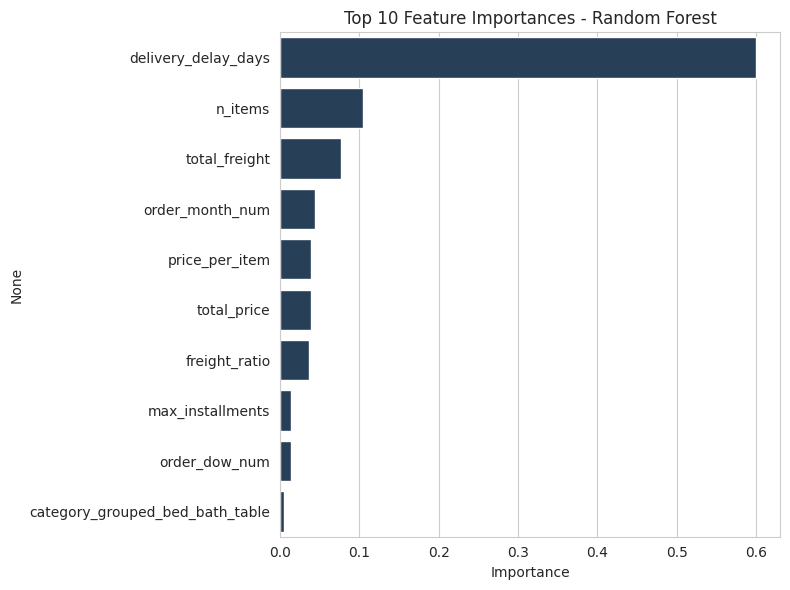

delivery_delay_days                0.600233
n_items                            0.104586
total_freight                      0.076737
order_month_num                    0.044515
price_per_item                     0.039467
total_price                        0.038989
freight_ratio                      0.036408
max_installments                   0.013888
order_dow_num                      0.013161
category_grouped_bed_bath_table    0.004715
dtype: float64

In [0]:
importances = pd.Series(rf_tuned.feature_importances_, index=all_features_v2).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, color="#1F3F5F")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(10)

**Finding:** delivery_delay_days should come out on top (or near it) here - which lines up with the -0.27 correlation with review_score found in the diagnostic section of the EDA notebook. Good sign that the model is picking up a real, already-validated pattern rather than noise.

## 12. Save the Final Model

In [0]:
joblib.dump(rf_tuned, "low_review_model.pkl")
joblib.dump(scaler, "scaler.pkl") 
joblib.dump(list(all_features_v2), "model_features.pkl")

print("Model and supporting files saved.")

## 13. Conclusion

- Target: is_low_review (review score of 1-2 stars), built from the same base table as the EDA notebook.
- Started with a plain numeric-only Logistic Regression baseline (Trial 1) - accuracy looked fine but recall on the minority class was weak, which isn't useful for the actual goal of flagging at-risk orders.
- Added feature engineering (price_per_item, freight_ratio, grouped product categories), one-hot encoding for categorical columns, and scaling for the numeric ones.
- Re-ran Logistic Regression with class_weight="balanced" (Trial 2), then tried Random Forest (Trial 3) and tuned it with a small GridSearchCV, optimizing for recall rather than accuracy since that fits the business goal better.
- Compared both models side by side on Accuracy, Precision, Recall, F1 and ROC-AUC, and picked the one with the better recall on the low-review class.
- Feature importance confirms delivery_delay_days is the strongest driver, consistent with the diagnostic finding from the EDA notebook.


